In [2855]:
import random
import cirq
import numpy as np
import matplotlib.pyplot as plt

# Circuit Builder

In [2856]:
def pauli_error(qubit, p):
    pauli_gates = [cirq.I, cirq.X, cirq.Y, cirq.Z]
    gate = np.random.choice(pauli_gates, p=[1 - p, p / 3, p / 3, p / 3])
    return gate(qubit)

def two_qubit_pauli_error(q1, q2, p):
    paulis = [cirq.I, cirq.X, cirq.Y, cirq.Z]

    two_qubit_ops = [
        (a, b)
        for a in paulis
        for b in paulis
        if not (a == cirq.I and b == cirq.I)
    ]  # 15 elements
    if np.random.rand() >= p:
        return [cirq.I(q1), cirq.I(q2)]  # No error

    a, b = random.choice(two_qubit_ops)
    return a(q1), b(q2)

In [2857]:
two_qubit_pauli_error(cirq.LineQubit(0), cirq.LineQubit(1), 0.1)

[cirq.I(cirq.LineQubit(0)), cirq.I(cirq.LineQubit(1))]

In [2858]:
def build_logic_circuit(register, logical_state="0L", flag_qubit=None, flag_key="flag", noise=0):
    """Build the 7-qubit 0L/1L-style circuit used in this notebook."""
    if len(register) < 7:
        raise ValueError("This circuit structure needs at least 7 qubits.")

    circuit = cirq.Circuit()

    # initialization depolarization noise
    circuit.append(cirq.Moment([pauli_error(q, noise) for q in register]))

    init_ops = [cirq.H(register[0]), cirq.H(register[1])]
    init_ops_noise = [pauli_error(register[0], noise), pauli_error(register[1], noise)]

    if logical_state == "1L" or logical_state == "minusL":
        init_ops.append(cirq.X(register[2]))
        init_ops_noise.append(pauli_error(register[2], noise))

    init_ops.append(cirq.H(register[3]))
    init_ops_noise.append(pauli_error(register[3], noise))

    circuit.append(cirq.Moment(init_ops))
    circuit.append(cirq.Moment(init_ops_noise))

    circuit.append(cirq.Moment([cirq.CNOT(register[2], register[4])]))
    circuit.append(cirq.Moment(two_qubit_pauli_error(register[2], register[4], noise)))
    circuit.append(cirq.Moment([cirq.CNOT(register[0], register[6])]))
    circuit.append(cirq.Moment(two_qubit_pauli_error(register[0], register[6], noise)))
    circuit.append(cirq.Moment([cirq.CNOT(register[3], register[5])]))
    circuit.append(cirq.Moment(two_qubit_pauli_error(register[3], register[5], noise)))
    circuit.append(cirq.Moment([cirq.CNOT(register[2], register[5])]))
    circuit.append(cirq.Moment(two_qubit_pauli_error(register[2], register[5], noise)))
    circuit.append(cirq.Moment([cirq.CNOT(register[0], register[4])]))
    circuit.append(cirq.Moment(two_qubit_pauli_error(register[0], register[4], noise)))
    circuit.append(cirq.Moment([cirq.CNOT(register[1], register[6])]))
    circuit.append(cirq.Moment(two_qubit_pauli_error(register[1], register[6], noise)))
    circuit.append(cirq.Moment([cirq.CNOT(register[0], register[2])]))
    circuit.append(cirq.Moment(two_qubit_pauli_error(register[0], register[2], noise)))
    circuit.append(cirq.Moment([cirq.CNOT(register[1], register[5])]))
    circuit.append(cirq.Moment(two_qubit_pauli_error(register[1], register[5], noise)))
    circuit.append(cirq.Moment([cirq.CNOT(register[3], register[4])]))
    circuit.append(cirq.Moment(two_qubit_pauli_error(register[3], register[4], noise)))
    circuit.append(cirq.Moment([cirq.CNOT(register[1], register[2])]))
    circuit.append(cirq.Moment(two_qubit_pauli_error(register[1], register[2], noise)))
    circuit.append(cirq.Moment([cirq.CNOT(register[3], register[6])]))
    circuit.append(cirq.Moment(two_qubit_pauli_error(register[3], register[6], noise)))
    if flag_qubit is not None:
        # initialization depolarization noise on the flag qubit
        circuit.append(cirq.Moment([pauli_error(flag_qubit, noise)]))
        circuit.append(cirq.Moment([cirq.CNOT(register[2], flag_qubit)]))
        circuit.append(cirq.Moment(two_qubit_pauli_error(register[2], flag_qubit, noise)))
        circuit.append(cirq.Moment([cirq.CNOT(register[4], flag_qubit)]))
        circuit.append(cirq.Moment(two_qubit_pauli_error(register[4], flag_qubit, noise)))
        circuit.append(cirq.Moment([cirq.CNOT(register[5], flag_qubit)]))
        circuit.append(cirq.Moment(two_qubit_pauli_error(register[5], flag_qubit, noise)))
        # Measurement error noise
        circuit.append(cirq.Moment([pauli_error(flag_qubit, noise)]))
        circuit.append(cirq.Moment([cirq.measure(flag_qubit, key=flag_key)]))

    if logical_state == "plusL" or logical_state == "minusL":
        circuit.append(cirq.Moment([cirq.H(register[q]) for q in range(7)]))
        circuit.append(cirq.Moment([pauli_error(q, noise) for q in register]))

    return circuit



# Hello Qubit

In [2859]:
# Pick a qubit.
qubit = cirq.GridQubit(0, 0)

# Create a circuit that applies a square root of NOT gate, then measures the qubit.
circuit = cirq.Circuit(cirq.X(qubit) ** 0.5, cirq.measure(qubit, key='m'))
print("Circuit:")
print(circuit)

# Simulate the circuit several times.
simulator = cirq.CliffordSimulator()
result = simulator.run(circuit, repetitions=20)
print("Results:")
print(result)

Circuit:
(0, 0): ───X^0.5───M('m')───
Results:
m=00011001000100001000


# 3b)

In [2860]:
register_7 = [cirq.LineQubit(i) for i in range(7)]
circuit_0L = build_logic_circuit(register_7, "0L", noise=1)
print("Circuit for logical state 0L:")
print(circuit_0L)

Circuit for logical state 0L:
0: ───Y───H───Z───────────@───Y───────────────────@───X───────────@───X───────────────────────────────────
                          │                       │               │
1: ───Z───H───Z───────────┼───────────────────────┼───────@───I───┼───────@───Z───────────@───I───────────
                          │                       │       │       │       │               │
2: ───X───────────@───X───┼───────────────@───Z───┼───────┼───────X───I───┼───────────────X───Y───────────
                  │       │               │       │       │               │
3: ───Z───H───Z───┼───────┼───────@───X───┼───────┼───────┼───────────────┼───────@───Z───────────@───Z───
                  │       │       │       │       │       │               │       │               │
4: ───Z───────────X───I───┼───────┼───────┼───────X───Y───┼───────────────┼───────X───X───────────┼───────
                          │       │       │               │               │                       │

In [2861]:
circuit_1L = build_logic_circuit(register_7, "1L")
print("Circuit for logical state 1L:")
print(circuit_1L)

Circuit for logical state 1L:
0: ───I───H───I───────────@───I───────────────────@───I───────────@───I───────────────────────────────────
                          │                       │               │
1: ───I───H───I───────────┼───────────────────────┼───────@───I───┼───────@───I───────────@───I───────────
                          │                       │       │       │       │               │
2: ───I───X───I───@───I───┼───────────────@───I───┼───────┼───────X───I───┼───────────────X───I───────────
                  │       │               │       │       │               │
3: ───I───H───I───┼───────┼───────@───I───┼───────┼───────┼───────────────┼───────@───I───────────@───I───
                  │       │       │       │       │       │               │       │               │
4: ───I───────────X───I───┼───────┼───────┼───────X───I───┼───────────────┼───────X───I───────────┼───────
                          │       │       │               │               │                       │

In [2862]:
simulator = cirq.Simulator()
result_0L = simulator.simulate(circuit_0L, qubit_order=register_7)
state_0L = result_0L.final_state_vector

print("Final state vector 0L:")
print(cirq.dirac_notation(state_0L, qid_shape=[2] * len(register_7), decimals=3))

result_1L = simulator.simulate(circuit_1L, qubit_order=register_7)
state_1L = result_1L.final_state_vector

print("Final state vector 1L:")
print(cirq.dirac_notation(state_1L, qid_shape=[2] * len(register_7), decimals=3))


Final state vector 0L:
0.354j|0000101⟩ + 0.354j|0001010⟩ + 0.354j|0110110⟩ + 0.354j|0111001⟩ - 0.354j|1010000⟩ - 0.354j|1011111⟩ - 0.354j|1100011⟩ - 0.354j|1101100⟩
Final state vector 1L:
0.354|0010110⟩ + 0.354|0011001⟩ + 0.354|0100101⟩ + 0.354|0101010⟩ + 0.354|1000011⟩ + 0.354|1001100⟩ + 0.354|1110000⟩ + 0.354|1111111⟩


# 3c)

In [2863]:
circuit_0L = build_logic_circuit(register_7, "0L", flag_qubit=cirq.LineQubit(7))
circuit_1L = build_logic_circuit(register_7, "1L", flag_qubit=cirq.LineQubit(7))
print("Circuits with measurement:")
print(circuit_0L)
print(circuit_1L)

Circuits with measurement:
0: ───I───H───I───────────@───I───────────────────@───I───────────@───I───────────────────────────────────────────────────────────────────────────────
                          │                       │               │
1: ───I───H───I───────────┼───────────────────────┼───────@───I───┼───────@───I───────────@───I───────────────────────────────────────────────────────
                          │                       │       │       │       │               │
2: ───I───────────@───I───┼───────────────@───I───┼───────┼───────X───I───┼───────────────X───I───────────────@───I───────────────────────────────────
                  │       │               │       │       │               │                                   │
3: ───I───H───I───┼───────┼───────@───I───┼───────┼───────┼───────────────┼───────@───I───────────@───I───────┼───────────────────────────────────────
                  │       │       │       │       │       │               │       │              

In [2864]:
simulator = cirq.Simulator()
result = simulator.run(circuit_0L, repetitions=20)

# Summary counts
print(result.histogram(key='flag'))

simulator = cirq.Simulator()
result = simulator.run(circuit_1L, repetitions=20)

# Summary counts
print(result.histogram(key='flag'))

Counter({0: 20})
Counter({1: 20})


In [2865]:
result = simulator.run(circuit_0L, repetitions=1)
bit = bool(result.measurements['flag'][0][0])
if bit == 0:
    print("0L is the following state:")
    print(cirq.dirac_notation(state_0L, qid_shape=[2] * len(register_7), decimals=3))

result = simulator.run(circuit_1L, repetitions=1)
bit = bool(result.measurements['flag'][0][0])
if bit == 1:
    print("1L is the following state:")
    print(cirq.dirac_notation(state_1L, qid_shape=[2] * len(register_7), decimals=3))

0L is the following state:
0.354j|0000101⟩ + 0.354j|0001010⟩ + 0.354j|0110110⟩ + 0.354j|0111001⟩ - 0.354j|1010000⟩ - 0.354j|1011111⟩ - 0.354j|1100011⟩ - 0.354j|1101100⟩
1L is the following state:
0.354|0010110⟩ + 0.354|0011001⟩ + 0.354|0100101⟩ + 0.354|0101010⟩ + 0.354|1000011⟩ + 0.354|1001100⟩ + 0.354|1110000⟩ + 0.354|1111111⟩


In [2866]:
circuit_plusL = build_logic_circuit(register_7, "plusL", flag_qubit=cirq.LineQubit(7))
circuit_minusL = build_logic_circuit(register_7, "minusL", flag_qubit=cirq.LineQubit(7))

print(circuit_plusL)
print(circuit_minusL)

0: ───I───H───I───────────@───I───────────────────@───I───────────@───I───────────────────────────────────────────────────────────────────────────────H───I───
                          │                       │               │
1: ───I───H───I───────────┼───────────────────────┼───────@───I───┼───────@───I───────────@───I───────────────────────────────────────────────────────H───I───
                          │                       │       │       │       │               │
2: ───I───────────@───I───┼───────────────@───I───┼───────┼───────X───I───┼───────────────X───I───────────────@───I───────────────────────────────────H───I───
                  │       │               │       │       │               │                                   │
3: ───I───H───I───┼───────┼───────@───I───┼───────┼───────┼───────────────┼───────@───I───────────@───I───────┼───────────────────────────────────────H───I───
                  │       │       │       │       │       │               │       │         

In [2867]:
all_qubits = list(register_7) + [cirq.LineQubit(7)]

result_plusL = simulator.simulate(circuit_plusL, qubit_order=all_qubits)
flag_bits_plusL = np.asarray(result_plusL.measurements['flag']).reshape(-1)
bit = int(flag_bits_plusL[0])

if bit == 0:
    state_plusL = result_plusL.final_state_vector
    print("The following state 0 after transversal H is:")
    print(cirq.dirac_notation(state_plusL, qid_shape=[2] * len(all_qubits), decimals=3))

result_minusL = simulator.simulate(circuit_minusL, qubit_order=all_qubits)
flag_bits_minusL = np.asarray(result_minusL.measurements['flag']).reshape(-1)
bit = int(flag_bits_minusL[0])

if bit == 1:
    state_minusL = result_minusL.final_state_vector
    print("The following state 1 after transversal H is:")
    print(cirq.dirac_notation(state_minusL, qid_shape=[2] * len(all_qubits), decimals=3))


The following state 0 after transversal H is:
0.25|00000000⟩ + 0.25|00011110⟩ + 0.25|00101100⟩ + 0.25|00110010⟩ + 0.25|01001010⟩ + 0.25|01010100⟩ + 0.25|01100110⟩ + 0.25|01111000⟩ + 0.25|10000110⟩ + 0.25|10011000⟩ + 0.25|10101010⟩ + 0.25|10110100⟩ + 0.25|11001100⟩ + 0.25|11010010⟩ + 0.25|11100000⟩ + 0.25|11111110⟩
The following state 1 after transversal H is:
0.25|00000001⟩ + 0.25|00011111⟩ - 0.25|00101101⟩ - 0.25|00110011⟩ - 0.25|01001011⟩ - 0.25|01010101⟩ + 0.25|01100111⟩ + 0.25|01111001⟩ - 0.25|10000111⟩ - 0.25|10011001⟩ + 0.25|10101011⟩ + 0.25|10110101⟩ + 0.25|11001101⟩ + 0.25|11010011⟩ - 0.25|11100001⟩ - 0.25|11111111⟩


In [2868]:
def transversal_CNOT(control_circuit, target_circuit, control_register, target_register, add_to_circuit=None, flags=None, measurement=None, noise=0):
    """Build control/target logical blocks in parallel, then apply transversal CNOTs."""
    flag_control = flags[0] if flags else None
    flag_target = flags[1] if flags else None

    combined = control_circuit + target_circuit

    for j in range(7):
        combined.append(cirq.Moment([cirq.CNOT(control_register[j], target_register[j])]))
        combined.append(cirq.Moment(two_qubit_pauli_error(control_register[j], target_register[j], noise)))

    # only used in the noise free case so that we can measure the flag qubits to see if they are in the correct state so no noise is added to the flag qubits
    if flag_control is not None and flag_target is not None:
        combined.append(cirq.Moment([cirq.CNOT(control_register[2], flag_control)], [cirq.CNOT(target_register[2], flag_target)]))
        combined.append(cirq.Moment([cirq.CNOT(control_register[4], flag_control)], [cirq.CNOT(target_register[4], flag_target)]))
        combined.append(cirq.Moment([cirq.CNOT(control_register[5], flag_control)], [cirq.CNOT(target_register[5], flag_target)]))
        combined.append(cirq.Moment([cirq.measure(flag_control, key="flag_0")], [cirq.measure(flag_target, key="flag_1")]))

    if measurement == "target" or measurement == "target_2":
        # error noise before measurement on the target qubits
        combined.append(cirq.Moment([pauli_error(q, noise) for q in target_register]))
        combined.append(cirq.Moment([cirq.measure(*target_register, key=measurement)]))
    elif measurement == "control" or measurement == "control_2":
        combined.append(cirq.Moment([cirq.H(control_register[q]) for q in range(7)]))
        # error after Hadamard on the control qubits
        combined.append(cirq.Moment([pauli_error(q, noise) for q in control_register]))
        # error noise before measurement on the control qubits
        combined.append(cirq.Moment([pauli_error(q, noise) for q in control_register]))
        combined.append(cirq.Moment([cirq.measure(*control_register, key=measurement)]))

    if add_to_circuit is not None:
        combined = add_to_circuit + combined
    return combined




In [2869]:
register_0 = cirq.LineQubit.range(7)              # data: 0..6
flags = [cirq.LineQubit(7), cirq.LineQubit(8), cirq.LineQubit(9)]    # dedicated flags: 7,8,9
register_1 = cirq.LineQubit.range(10, 17)           # data: 9..15

In [2870]:
control_circuit_0L = build_logic_circuit(register_0, "0L")
target_circuit_0L = build_logic_circuit(register_1, "0L")

circuit = transversal_CNOT(
    control_circuit_0L,
    target_circuit_0L,
    control_register=register_0,
    target_register=register_1,
    flags=flags,
 )
print(circuit)

0: ────I───H───I───────────@───I───────────────────@───I───────────@───I───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────@───I─────────────────────────────────────────────────────────────────────────────
                           │                       │               │                                                                                                                                           │
1: ────I───H───I───────────┼───────────────────────┼───────@───I───┼───────@───I───────────@───I───────────────────────────────────────────────────────────────────────────────────────────────────────────────┼───────@───I─────────────────────────────────────────────────────────────────────
                           │                       │       │       │       │               │                                                                                                                   │   

# 3d)

In [2871]:
def check_transversal_flags(
    control_circuit,
    target_circuit,
    control_register,
    target_register,
    control_label,
    target_label,
    flags=flags,
 ):
    circuit = transversal_CNOT(
        control_circuit,
        target_circuit,
        control_register,
        target_register,
        flags=flags,
    )
    result = simulator.run(circuit, repetitions=1)
    flag_0 = int(result.measurements['flag_0'][0][0])
    flag_1 = int(result.measurements['flag_1'][0][0])
    print(f"{control_label},{target_label} -> {flag_0}L,{flag_1}L")
    return flag_0, flag_1


basis_pairs = [
    ("0L", "0L", build_logic_circuit(register_0, "0L"), build_logic_circuit(register_1, "0L")),
    ("0L", "1L", build_logic_circuit(register_0, "0L"), build_logic_circuit(register_1, "1L")),
    ("1L", "0L", build_logic_circuit(register_0, "1L"), build_logic_circuit(register_1, "0L")),
    ("1L", "1L", build_logic_circuit(register_0, "1L"), build_logic_circuit(register_1, "1L")),
]
for control_label, target_label, control_circuit, target_circuit in basis_pairs:
    check_transversal_flags(
        control_circuit,
        target_circuit,
        register_0,
        register_1,
        control_label,
        target_label,
        flags=flags,
    )

0L,0L -> 0L,0L
0L,1L -> 0L,1L
1L,0L -> 1L,1L
1L,1L -> 1L,0L


In [2872]:
control_circuit = build_logic_circuit(register_1, "0L")
target_circuit = build_logic_circuit(register_0, "0L")

circuit = transversal_CNOT(
    control_circuit,
    target_circuit,
    control_register=register_1,
    target_register=register_0,
    flags=flags,
 )
print(circuit)

                                                                                                                                                                                                                                                                       ┌──┐   ┌──┐   ┌──┐
0: ────────────────────────────────────────────────────────────────────────────────────────────────────────I───H───I───────────@───I───────────────────@───I───────────@───I───────────────────────────────────X───I──────────────────────────────────────────────────────────────────────────────────────
                                                                                                                               │                       │               │                                       │
1: ────────────────────────────────────────────────────────────────────────────────────────────────────────I───H───I───────────┼───────────────────────┼───────@───I───┼───────@───I───────────@───I───────────┼──

In [2873]:
reverse_basis_pairs = [
    ("0L", "0L", build_logic_circuit(register_1, "0L"), build_logic_circuit(register_0, "0L")),
    ("0L", "1L", build_logic_circuit(register_1, "0L"), build_logic_circuit(register_0, "1L")),
    ("1L", "0L", build_logic_circuit(register_1, "1L"), build_logic_circuit(register_0, "0L")),
    ("1L", "1L", build_logic_circuit(register_1, "1L"), build_logic_circuit(register_0, "1L")),
]

for control_label, target_label, control_circuit, target_circuit in reverse_basis_pairs:
    check_transversal_flags(
        control_circuit,
        target_circuit,
        register_1,
        register_0,
        control_label,
        target_label,
        flags=flags,
    )

0L,0L -> 0L,0L
0L,1L -> 0L,1L
1L,0L -> 1L,1L
1L,1L -> 1L,0L


In [2874]:
parity_check_matrix = np.array([[1, 0, 1, 0, 1, 0, 1],
                                [0, 1, 1, 0, 0, 1, 1],
                                [0, 0, 0, 1, 1, 1, 1],])

def syndromes(measurement_results):
    """Extract the syndrome from the measurement results."""
    syndromes = measurement_results @ parity_check_matrix.T % 2
    return syndromes

print("Parity check matrix:")
print(parity_check_matrix)

result = np.array([[0, 1, 1, 0, 1, 1, 0]])

syndrome = syndromes(result)
print("Syndrome for the measurement results:")
print(syndrome)

Parity check matrix:
[[1 0 1 0 1 0 1]
 [0 1 1 0 0 1 1]
 [0 0 0 1 1 1 1]]
Syndrome for the measurement results:
[[0 1 0]]


In [2875]:
look_up_table = {
    (0, 0, 0): -1,
    (1, 0, 0): 0,
    (0, 1, 0): 1,
    (1, 1, 0): 2,
    (0, 0, 1): 3,
    (1, 0, 1): 4,
    (0, 1, 1): 5,
    (1, 1, 1): 6,
}

In [2876]:
def decoder(sx_vector, sz_vector):
    """Decode the syndrome vectors to identify the error location."""
    # Convert to tuples for lookup
    sx_tuple = tuple(sx_vector)
    sz_tuple = tuple(sz_vector)

    # Look up the error locations using the predefined look-up table
    x_error_location = look_up_table.get(sx_tuple, -1)  # -1 indicates no error
    z_error_location = look_up_table.get(sz_tuple, -1)  # -1 indicates no error

    return x_error_location, z_error_location

In [2877]:
def build_correction_circuit(psi, register_0, register_1, register_2, error=None, tomography=True, noise=(0,0)):
    # Stage 1: control register_0 -> target register_1
    control_circuit = build_logic_circuit(
        register_0,
        psi,
        flag_qubit=flags[0],
        flag_key="flag_stage1",
        noise=noise[0]
    )
    if error is not None:
        error_type = error[0]
        error_qubit_index = int(error[1])
        gate_map = {"X": cirq.X, "Y": cirq.Y, "Z": cirq.Z}
        if error_type not in gate_map:
            raise ValueError("error_type must be 'X', 'Y', or 'Z'.")
        control_circuit.append(
            cirq.Moment([gate_map[error_type](register_0[error_qubit_index])])
        )  # Introduce error on the control register
    target_circuit_1 = build_logic_circuit(
        register_1, "plusL",
        flag_qubit=flags[1],
        flag_key="flag_stage2",
        noise=noise[1]
    )
    stage_1 = transversal_CNOT(
        control_circuit,
        target_circuit_1,
        register_0,
        register_1,
        measurement="target", #  No measurement if total
        noise=noise[1]
    )

    # Stage 2: add the other transversal CNOTs, control register_2 -> target register_0
    control_circuit_2 = build_logic_circuit(
        register_2,
        "0L",
        flag_qubit=flags[2],
        flag_key="flag_stage3",
        noise=noise[1]
    )
    stage_2 = transversal_CNOT(
        control_circuit_2,
        cirq.Circuit(),
        register_2,
        register_0,
        add_to_circuit=stage_1,
        measurement="control",
        noise=noise[1]
    )

    if tomography:
    # state tomography
        if psi == "plusL" or psi == "minusL":
            # Logical X measurement (change basis first)
            stage_2.append(cirq.Moment([cirq.H(register_0[q]) for q in range(7)]))
            stage_2.append(cirq.measure(*register_0, key="logical"))
        else:
            # Logical Z measurement (physical Z basis)
            stage_2.append(cirq.measure(*register_0, key="logical"))

    return stage_2

register_2 = cirq.LineQubit.range(17, 24)

circuit = build_correction_circuit("plusL", register_0, register_1, register_2, error="Y2")

print(circuit)

0: ────I───H───I───────────@───I───────────────────@───I───────────@───I──────────────────────────────────────────────────────────────────────────────────────H───I──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────@───I────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────X───I──────────────────────────────────────────────────────────────────────────────H───M('logical')───
                           │                       │               │                                                                                                                                                                                                                                                                     │             

In [2878]:
result = simulator.run(circuit, repetitions=1)

def measure_syndromes(result, printed=False, target='target', control='control'):
    # Each measurement array has shape (repetitions, 7).
    target_measurements = result.measurements[target]
    control_measurements = result.measurements[control]
    if printed:
        print("Control register measurement results:", control_measurements)
        print("Target register measurement results:", target_measurements)

    # Compute one 3-bit syndrome per repetition.
    sx_vectors = syndromes(target_measurements)
    sz_vectors = syndromes(control_measurements)

    return sx_vectors, sz_vectors

sx_vectors, sz_vectors = measure_syndromes(result, printed=True)
print("Syndrome vectors for the target register:", sx_vectors)
print("Syndrome vectors for the control register:", sz_vectors)

Control register measurement results: [[1 1 0 1 1 1 1]]
Target register measurement results: [[0 0 0 0 1 1 0]]
Syndrome vectors for the target register: [[1 1 0]]
Syndrome vectors for the control register: [[1 1 0]]


# 3e)

In [2879]:
print("Decoding the syndrome vectors...")
x_error_location, z_error_location = decoder(sx_vectors[0], sz_vectors[0])
print(f"X error location: {x_error_location}")
print(f"Z error location: {z_error_location}")

Decoding the syndrome vectors...
X error location: 2
Z error location: 2


In [2880]:
circuit_0L = build_logic_circuit(register_0, "0L")
result = simulator.simulate(circuit_0L, qubit_order=register_0)
state_0L = result.final_state_vector
circuit_1L = build_logic_circuit(register_0, "1L")
result = simulator.simulate(circuit_1L, qubit_order=register_0)
state_1L = result.final_state_vector
circuit_plusL = build_logic_circuit(register_0, "plusL")
result = simulator.simulate(circuit_plusL, qubit_order=register_0)
state_plusL = result.final_state_vector
circuit_minusL = build_logic_circuit(register_0, "minusL")
result = simulator.simulate(circuit_minusL, qubit_order=register_0)
state_minusL = result.final_state_vector

initial_state_vectors = [state_0L, state_1L, state_plusL, state_minusL]


In [2881]:
# single-qubit depolarizing channel
def one_qubit_depol(p):
    return cirq.depolarize(p)

# two-qubit depolarizing channel this is the error channel that was asked for
def two_qubit_depol(p):
    return cirq.DepolarizingChannel(p, n_qubits=2)

In [2882]:
psi = "0L"
p = 1
noise = (p, p)

correction_circuit = build_correction_circuit(
    psi, register_0, register_1, register_2, noise=noise, tomography=False
)       


def build_full_correction_circuit(psi, correction_circuit, register_0, register_1, register_2):
    control_circuit = correction_circuit

    # Perfect round of error correction, no noise, no errors
    target_circuit_1 = build_logic_circuit(
        register_1, "plusL",
        noise=0
    )
    stage_1 = transversal_CNOT(
        control_circuit,
        target_circuit_1,
        register_0,
        register_1,
        measurement="target_2", #  No measurement if total
        noise=0
    )

    # Stage 2: add the other transversal CNOTs, control register_2 -> target register_0
    control_circuit_2 = build_logic_circuit(
        register_2,
        "0L",
        noise=0
    )
    stage_2 = transversal_CNOT(
        control_circuit_2,
        cirq.Circuit(),
        register_2,
        register_0,
        add_to_circuit=stage_1,
        measurement="control_2",
        noise=0
    )

    if psi == "plusL" or psi == "minusL":
        # Logical X measurement (change basis first)
        stage_2.append(cirq.Moment([cirq.H(register_0[q]) for q in range(7)]))
        stage_2.append(cirq.measure(*register_0, key="logical_final"))
    else:
        # Logical Z measurement (physical Z basis)
        stage_2.append(cirq.measure(*register_0, key="logical_final"))
        pass

    return stage_2

register_3 = cirq.LineQubit.range(25, 32)
register_4 = cirq.LineQubit.range(32, 39)

full_correction_circuit = build_full_correction_circuit(psi, correction_circuit, register_0, register_3, register_4)
corrected_circuit = full_correction_circuit
print(full_correction_circuit)

0: ────Z───H───Y───────────@───Y───────────────────@───X───────────@───X─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────@───Y────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────X───Y──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────@───I───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────X───I───────────────────────────────────────────────────M('logical_final')─────────────────

In [2883]:
def error_correction_cycle(
    register_0,
    register_1,
    register_2,
    register_3=register_3,
    register_4=register_4,
    printed=False,
    error=None,
    repetitions=1,
    shots=1,
    noise=(0, 0),
    psi_reduced=False,
    full_round=False
    ):

    if printed:
        print(f"Running error correction cycle with error: {error}, and repetitions: {repetitions}")
    if psi_reduced:
        psi_list = ["0L", "plusL"]
    else:
        psi_list = ["0L", "1L", "plusL", "minusL"]

    fails_count_total = np.zeros(len(psi_list), dtype=int)
    false_flag_count_total = np.zeros(len(psi_list), dtype=int)

    for psi_state in psi_list:

        fails_count = 0

        false_flag_count = 0

        for _ in range(shots):

            correction_circuit = build_correction_circuit(
                psi_state, register_0, register_1, register_2, error=error, noise=noise
            )       

            if full_round:
                correction_circuit = build_full_correction_circuit(psi_state, correction_circuit, register_0, register_3, register_4)
    
            result = simulator.run(correction_circuit, repetitions=repetitions)

            flag_measurements = [f"flag_stage{i}" for i in range(1, 4)]

            if psi_state == "0L" or psi_state == "plusL":
                flag_0 = 0
            elif psi_state == "1L" or psi_state == "minusL":
                flag_0 = 1
            

            flag_measurements_dict = {key: result.measurements[key] for key in flag_measurements}

            skip_shot = False

            for key, measurements in flag_measurements_dict.items():
                if key == "flag_stage1":
                    expected_flag = flag_0
                elif key == "flag_stage2":
                    expected_flag = 0
                elif key == "flag_stage3":
                    expected_flag = 0

                for flag in measurements.flatten():
                    if flag != expected_flag:
                        if printed:
                            print(f"Error: Flag measurement {key} is {flag}, expected {expected_flag} for {psi_state}.")
                        false_flag_count += 1
                        skip_shot = True
                        break  # exit flag loop

                if skip_shot:
                    break  # exit flag_stage loop

            if skip_shot:
                continue  # skips the whole shot

            sx_vectors, sz_vectors = measure_syndromes(result)

            # Check if the syndrome measurements are consistent across repetitions
            if not np.all(sx_vectors == sx_vectors[0]) or not np.all(sz_vectors == sz_vectors[0]):
                raise ValueError(f"Error: Syndrome measurements are not consistent across repetitions for {psi_state}.")
            x_error_location, z_error_location = decoder(sx_vectors[0], sz_vectors[0])

            # If full_round is True, perform a second round of syndrome measurement and decoding of the perfect QEC cycle
            if full_round:
                sx_vectors_2, sz_vectors_2 = measure_syndromes(result, target='target_2', control='control_2', printed=printed)
                x_error_location_2, z_error_location_2 = decoder(sx_vectors_2[0], sz_vectors_2[0])

            if full_round:
                parity_results = result.measurements['logical_final'][0].copy()
            else:
                parity_results = result.measurements['logical'][0].copy()

            # Offline decoder for better performance
            if (psi_state == "0L" or psi_state == "1L") and x_error_location != -1:
                # binary addition
                parity_results[z_error_location] ^= 1
                if full_round:
                    parity_results[z_error_location_2] ^= 1
            elif (psi_state == "plusL" or psi_state == "minusL") and z_error_location != -1:
                parity_results[x_error_location] ^= 1
                if full_round:
                    parity_results[x_error_location_2] ^= 1


            parity = np.sum(parity_results.flatten()) % 2


            if psi_reduced:
                psi_state_parities = [0, 0]
            else:
                psi_state_parities = [0, 1, 0, 1] # Expected parities for 0L, 1L, plusL, minusL respectively

            if parity != psi_state_parities[psi_list.index(psi_state)]:
                if printed:
                    print(f"Final measurement for {psi_state} indicates a logical error after correction.")
                fails_count += 1
            else:
                if printed:
                    print(f"Final measurement for {psi_state} indicates no logical error after correction.")

        fails_count_total[psi_list.index(psi_state)] = fails_count
        false_flag_count_total[psi_list.index(psi_state)] = false_flag_count
    if printed:
        print(f"Total fails in logical qubits: {sum(fails for fails in fails_count_total)}")
        print(f"Total false flags: {sum(flags for flags in false_flag_count_total)}")
    return fails_count_total, false_flag_count_total

In [2884]:
fails_count_total, false_flag_count_total = error_correction_cycle(register_0, register_1, register_2, shots=1, noise=(0,0), full_round=True)

print(f"Total fails in logical qubits: {fails_count_total}")
print(f"False flags count: {false_flag_count_total}")

Total fails in logical qubits: [0 0 1 1]
False flags count: [0 0 0 0]


# 3f)

In [2885]:
error_correction_cycle(
    register_0, register_1, register_2, printed=True, repetitions=10**4
 )

Running error correction cycle with error: None, and repetitions: 10000
Final measurement for 0L indicates no logical error after correction.
Final measurement for 1L indicates no logical error after correction.
Final measurement for plusL indicates no logical error after correction.
Final measurement for minusL indicates no logical error after correction.
Total fails in logical qubits: 0
Total false flags: 0


(array([0, 0, 0, 0]), array([0, 0, 0, 0]))

# 3g)

In [2886]:
errors = ["X0", "X1", "X2", "X3", "X4", "X5", "X6",
          "Y0", "Y1", "Y2", "Y3", "Y4", "Y5", "Y6",
          "Z0", "Z1", "Z2", "Z3", "Z4", "Z5", "Z6"]

for error in errors:
    print(f"Testing error correction with error: {error}")
    error_correction_cycle(
        register_0, register_1, register_2, printed=True, error=error, repetitions=10**4
    )

Testing error correction with error: X0
Running error correction cycle with error: X0, and repetitions: 10000
Final measurement for 0L indicates no logical error after correction.
Final measurement for 1L indicates no logical error after correction.
Final measurement for plusL indicates no logical error after correction.
Final measurement for minusL indicates no logical error after correction.
Total fails in logical qubits: 0
Total false flags: 0
Testing error correction with error: X1
Running error correction cycle with error: X1, and repetitions: 10000
Final measurement for 0L indicates no logical error after correction.
Final measurement for 1L indicates no logical error after correction.
Final measurement for plusL indicates no logical error after correction.
Final measurement for minusL indicates no logical error after correction.
Total fails in logical qubits: 0
Total false flags: 0
Testing error correction with error: X2
Running error correction cycle with error: X2, and repetit

In [2887]:
def bernoulli_sem(p_hat, N):
    return np.sqrt(p_hat * (1 - p_hat) / N)


def evaluate_point(register_0, register_1, register_2, p, shots=500, full_round=False, psi_reduced=False):
    
    fails_count_total, false_flag_count_total = error_correction_cycle(
        register_0,
        register_1,
        register_2,
        shots=shots,
        noise=(p, 0),
        full_round=full_round,
        psi_reduced=psi_reduced
    )

    # Acceptance probability
    P_acc = 1 - (false_flag_count_total.sum() / (shots*len(fails_count_total)))

    # avoid division by zero
    accepted_shots = max(shots*len(fails_count_total) - false_flag_count_total.sum(), 1)
    # Logical error rate
    LER = fails_count_total.sum() / accepted_shots

    # Error bars
    P_acc_err = bernoulli_sem(P_acc, shots*len(fails_count_total))
    LER_err = bernoulli_sem(LER, accepted_shots)

    return P_acc, P_acc_err, LER, LER_err


def sweep_noise(register_0, register_1, register_2, p_values, shots=500, full_round=False, psi_reduced=False):

    P_acc_values = []
    P_acc_errs = []

    LER_values = []
    LER_errs = []

    for p in p_values:
        P_acc, P_acc_err, LER, LER_err = evaluate_point(
            register_0, register_1, register_2, p, shots, full_round=full_round, psi_reduced=psi_reduced
        )

        P_acc_values.append(P_acc)
        P_acc_errs.append(P_acc_err)

        LER_values.append(LER)
        LER_errs.append(LER_err)

        print(f"p={p:.4f} | Pacc={P_acc:.4f} | LER={LER:.6f}")

    return (
        np.array(P_acc_values),
        np.array(P_acc_errs),
        np.array(LER_values),
        np.array(LER_errs),
    )


def quadratic_fit(p_values, ler_values):
    coeffs = np.polyfit(p_values, ler_values, 2)
    return coeffs  # A, B, C


# Plot
def plot_results(p_values, P_acc, P_acc_err, LER, LER_err, fit_coeffs, fit=True):

    A, B, C = fit_coeffs

    p_fit = np.linspace(min(p_values), max(p_values), 200)
    ler_fit = A * p_fit**2 + B * p_fit + C

    # --- Pacc plot ---
    plt.figure()
    plt.errorbar(p_values, P_acc, yerr=P_acc_err, marker='o', linestyle='-')
    plt.xlabel("Physical error rate p")
    plt.ylabel("Acceptance probability P_acc")
    plt.title("Acceptance Probability vs Noise")
    plt.grid()
    plt.show()

    # --- LER plot ---
    plt.figure()
    plt.errorbar(p_values, LER, yerr=LER_err, marker='o', linestyle='', label="data")
    plt.plot(p_fit, ler_fit, label="quadratic fit")
    plt.xlabel("Physical error rate p")
    plt.ylabel("Logical error rate p_L")
    plt.title("Logical Error Rate vs Noise")
    plt.legend()
    plt.grid()
    plt.show()

    if fit:
        print("\nQuadratic fit:")
        print(f"A = {A}")
        print(f"B = {B}")
        print(f"C = {C}")

        print("\nFault-tolerance check:")
        print("If B ~ 0 (within uncertainty), leading scaling is quadratic.")




# 3h)

p=0.0010 | Pacc=0.9875 | LER=0.000000
p=0.0050 | Pacc=0.9500 | LER=0.000000
p=0.0100 | Pacc=0.9750 | LER=0.025641
p=0.0200 | Pacc=0.8500 | LER=0.029412
p=0.0500 | Pacc=0.6750 | LER=0.092593


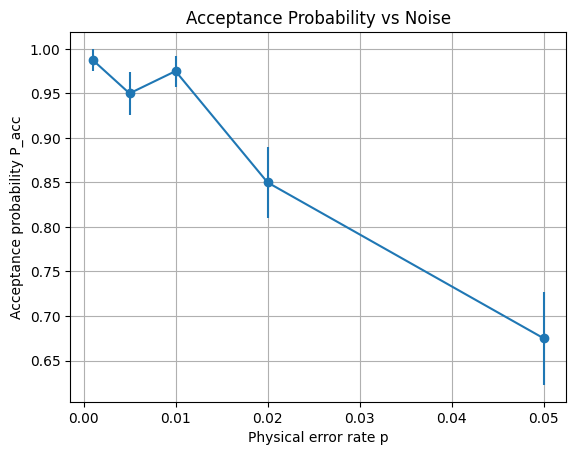

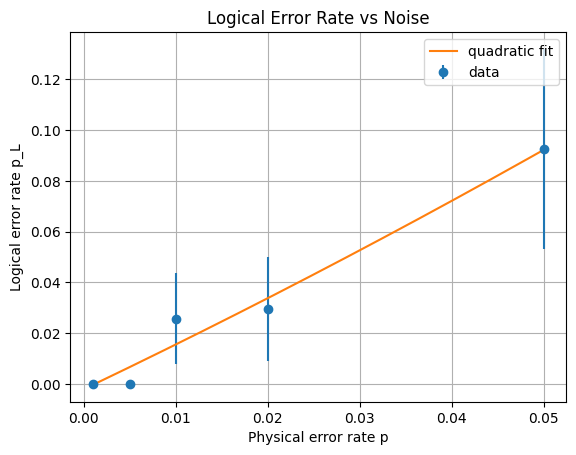


Quadratic fit:
A = 3.102079191928456
B = 1.7327124747993707
C = -0.002150956305604155

Fault-tolerance check:
If B ~ 0 (within uncertainty), leading scaling is quadratic.


In [2890]:
p_values = [0.001, 0.005, 0.01, 0.02, 0.05]

shots = 40

P_acc, P_acc_err, LER, LER_err = sweep_noise(
    register_0,
    register_1,
    register_2,
    p_values,
    shots=shots,
    psi_reduced=True
)

coeffs = quadratic_fit(p_values, LER)

plot_results(p_values, P_acc, P_acc_err, LER, LER_err, coeffs)

The leading quadratic term is definetly dominant but due to the high uncertainties B still could be around 0. It would have been better if the number of shots increased. But in general if the leading scale is quadratic it shows FT.

# 3i)

p=0.0010 | Pacc=0.9875 | LER=0.215190
p=0.0050 | Pacc=0.9750 | LER=0.179487
p=0.0100 | Pacc=0.8500 | LER=0.308824
p=0.0200 | Pacc=0.8375 | LER=0.253731
p=0.0500 | Pacc=0.6875 | LER=0.418182


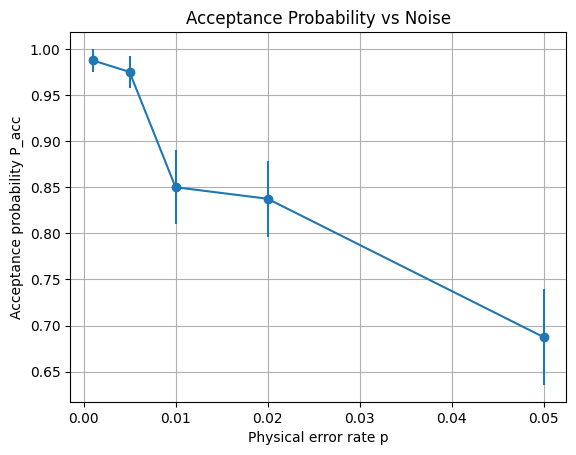

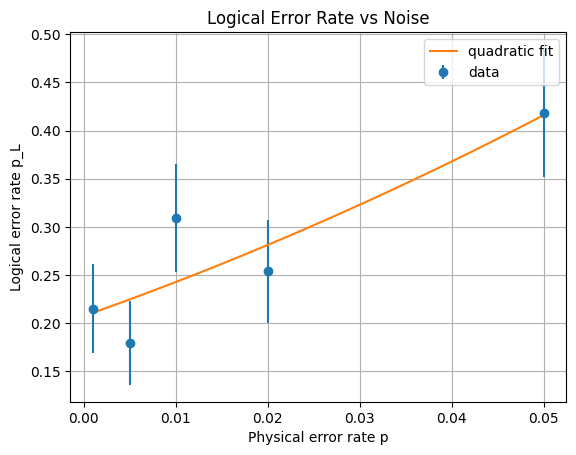

In [2892]:
p_values = [0.001, 0.005, 0.01, 0.02, 0.05]

shots = 20

P_acc, P_acc_err, LER, LER_err = sweep_noise(
    register_0,
    register_1,
    register_2,
    p_values,
    shots=shots,
    full_round=True
)

coeffs = quadratic_fit(p_values, LER)

plot_results(p_values, P_acc, P_acc_err, LER, LER_err, coeffs, fit=False)

There is probably a bug in the code, A LER over 0.25 is too much. I assume there is an issue withe the z correction in the second part